# Normal, Lognormal, and Weibull Distributions

**Module 3: Probability Distributions** | Lean Six Sigma Data Analytics

---

## Sample vs Population

```
SAMPLE (Histogram)              POPULATION (Curve)
┌─────────────────────┐         ┌─────────────────────┐
│   █                 │         │      ╱╲             │
│   █ █               │         │     ╱  ╲            │
│ █ █ █ █             │   ──►   │    ╱    ╲           │
│ █ █ █ █ █           │         │   ╱      ╲          │
│ █ █ █ █ █ █         │         │  ╱        ╲         │
└─────────────────────┘         └─────────────────────┘
  Blue bars = data               Red curve = fitted
  from sample                    distribution
```

- **Histogram:** Represents the sample (what we measured)
- **Curve:** Represents the population (probability distribution)

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')


Data loaded successfully!


---

## Three Key Distributions

There are hundreds of probability distributions, but in Lean Six Sigma projects you mostly encounter just three:

| Distribution | Shape | Common Use |
|--------------|-------|------------|
| **Normal** | Symmetrical (bell-shaped) | Most common; many natural phenomena |
| **Weibull** | Skewed to the right | Throughput times, processing times |
| **Lognormal** | Skewed to the right | Time data, financial data |

---

## 1. Normal Distribution

The normal distribution is:
- **Symmetrical** around the mean
- **Bell-shaped** (also called the "bell curve")
- The most commonly seen distribution

### Example: Caffeine Percentage in Coffee

In [2]:
# Load Caffeine data
caffeine = pd.read_excel(xlsx, sheet_name='Caffeine_batches', skiprows=6, usecols=[0, 1])
caffeine.columns = ['Batch', 'Caffeine_Pct']
caffeine = caffeine.dropna()
caffeine['Caffeine_Pct'] = pd.to_numeric(caffeine['Caffeine_Pct'], errors='coerce')
caffeine = caffeine.dropna()

data_normal = caffeine['Caffeine_Pct']
print(f'Sample size: {len(data_normal)}')
print(f'Mean: {data_normal.mean():.4f}')
print(f'Std Dev: {data_normal.std():.4f}')

Sample size: 40
Mean: 0.0832
Std Dev: 0.0164


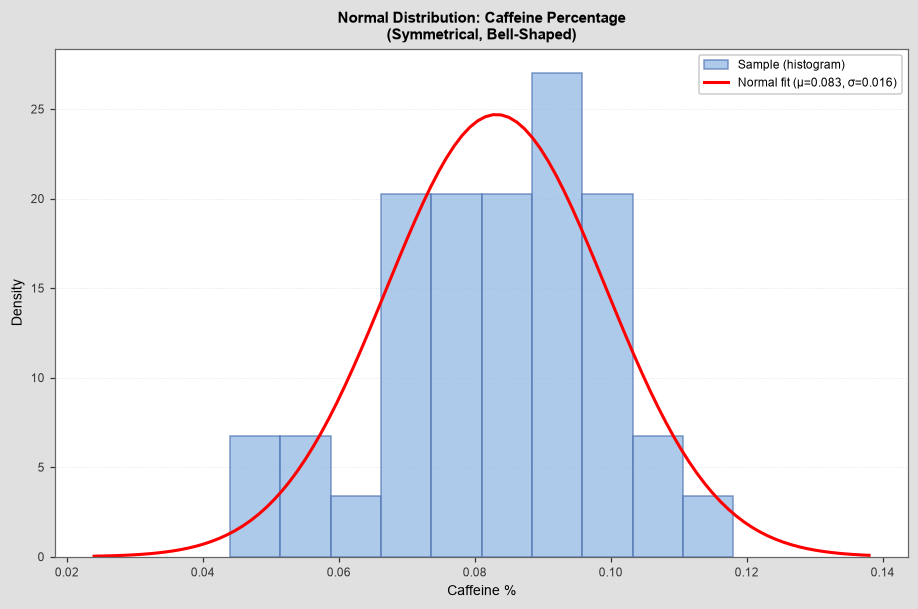

The data looks like a bell shape - symmetrical around the mean.
The Normal distribution fits well.


In [3]:
# Histogram with fitted Normal distribution
plt.figure(figsize=(10, 6))

# Histogram (sample)
plt.hist(data_normal, bins=10, density=True, alpha=0.7, color=ms.HIST_FILL, 
         edgecolor=ms.HIST_EDGE, label='Sample (histogram)')

# Fit normal distribution (population estimate)
mu, sigma = stats.norm.fit(data_normal)
x_range = np.linspace(data_normal.min() - 0.02, data_normal.max() + 0.02, 100)
plt.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'r-', lw=2, 
         label=f'Normal fit (μ={mu:.3f}, σ={sigma:.3f})')

plt.xlabel('Caffeine %')
plt.ylabel('Density')
plt.title('Normal Distribution: Caffeine Percentage\n(Symmetrical, Bell-Shaped)')
plt.legend()
plt.show()

print('The data looks like a bell shape - symmetrical around the mean.')
print('The Normal distribution fits well.')

### Sample Size Effect

With only 40-50 values, you need some imagination to see the bell shape. As sample size increases, the histogram converges more clearly to the bell shape.

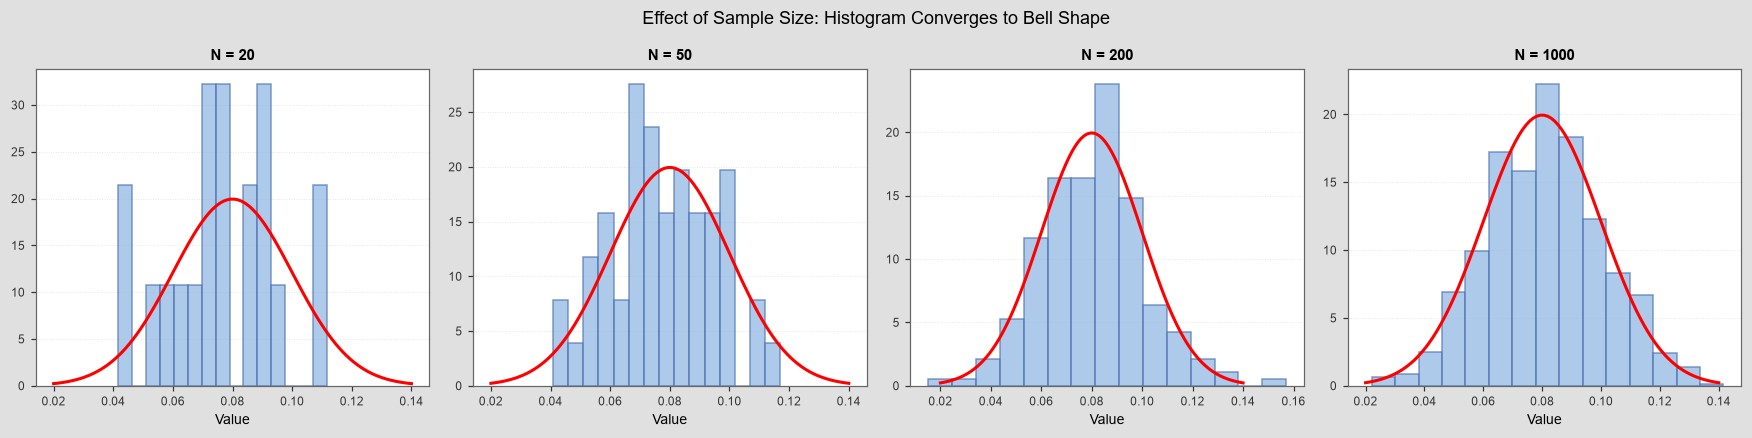

As N increases, the histogram looks more and more like the bell-shaped curve.


In [4]:
# Demonstrate effect of sample size
np.random.seed(42)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sample_sizes = [20, 50, 200, 1000]
true_mu, true_sigma = 0.08, 0.02

for ax, n in zip(axes, sample_sizes):
    sample = np.random.normal(true_mu, true_sigma, n)
    ax.hist(sample, bins=15, density=True, alpha=0.7, color=ms.HIST_FILL, edgecolor=ms.HIST_EDGE)
    x_range = np.linspace(0.02, 0.14, 100)
    ax.plot(x_range, stats.norm.pdf(x_range, true_mu, true_sigma), 'r-', lw=2)
    ax.set_title(f'N = {n}')
    ax.set_xlabel('Value')

plt.suptitle('Effect of Sample Size: Histogram Converges to Bell Shape', fontsize=12)
plt.tight_layout()
plt.show()

print('As N increases, the histogram looks more and more like the bell-shaped curve.')

---

## 2. Skewed Distributions

Not all data is symmetrical. **Skewed distributions** have a tail extending to one side.

- **Skewed to the right:** Long tail extends to the right (positive skew)
- Common for: Throughput times, processing times, waiting times
- Why? Many values are small, but some are very high

### Example: Throughput Times (Claims at a Bank)

*Data simulated to match course video example*

In [5]:
# Generate throughput time data matching the course video example
# (Claims at a bank - right-skewed distribution peaking around 20-30)
np.random.seed(42)

# Generate right-skewed data similar to course video
# Using a Weibull distribution with parameters that produce peak around 20-30
data_skewed = stats.weibull_min.rvs(c=1.8, scale=35, size=350)
data_skewed = pd.Series(data_skewed)

print('Throughput Time Data (Claims at a Bank)')
print(f'Sample size: {len(data_skewed)}')
print(f'Mean: {data_skewed.mean():.2f}')
print(f'Median: {data_skewed.median():.2f}')
print(f'Min: {data_skewed.min():.2f}, Max: {data_skewed.max():.2f}')
print(f'Skewness: {data_skewed.skew():.2f} (positive = skewed right)')

Throughput Time Data (Claims at a Bank)
Sample size: 350
Mean: 30.31
Median: 29.00
Min: 1.86, Max: 81.81
Skewness: 0.57 (positive = skewed right)


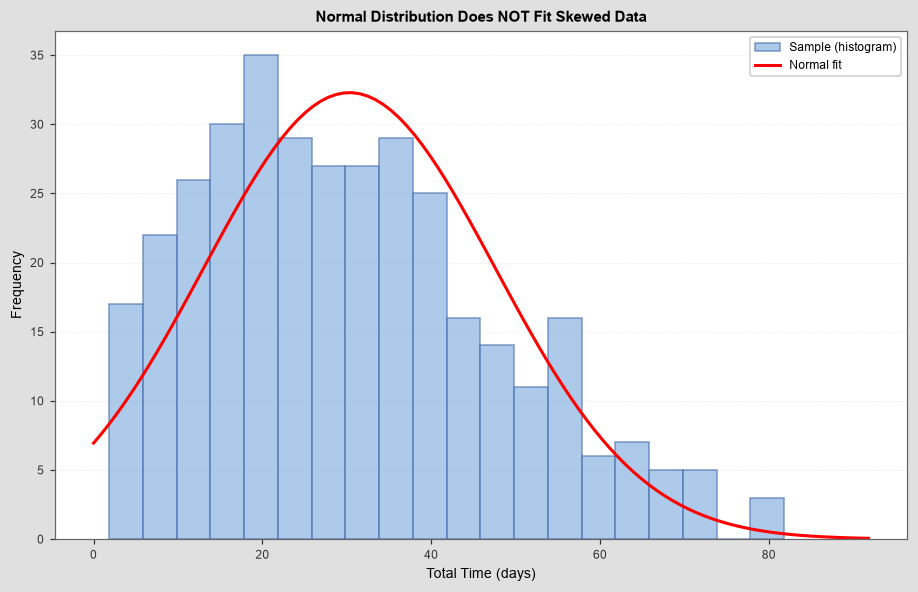

The Normal distribution does NOT fit well!
The histogram and curve have different shapes.
We need a different distribution...


In [6]:
# Does Normal distribution fit skewed data?
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (frequency, not density)
n_obs = len(data_skewed)
counts, bins, _ = ax.hist(data_skewed, bins=20, alpha=0.7, color=ms.HIST_FILL, 
                          edgecolor=ms.HIST_EDGE, label='Sample (histogram)')
bin_width = bins[1] - bins[0]

# Fit normal distribution and scale to frequency
norm_mu, norm_sigma = stats.norm.fit(data_skewed)
x_range = np.linspace(0, data_skewed.max() + 10, 100)
norm_pdf_scaled = stats.norm.pdf(x_range, norm_mu, norm_sigma) * n_obs * bin_width
ax.plot(x_range, norm_pdf_scaled, 'r-', lw=2, label='Normal fit')

ax.set_xlabel('Total Time (days)')
ax.set_ylabel('Frequency')
ax.set_title('Normal Distribution Does NOT Fit Skewed Data')
ax.legend()
plt.show()

print('The Normal distribution does NOT fit well!')
print('The histogram and curve have different shapes.')
print('We need a different distribution...')

---

## 3. Weibull Distribution

The **Weibull distribution** is skewed and often used for:
- Throughput times
- Processing times
- Reliability/survival data

It can take various forms depending on its parameters.

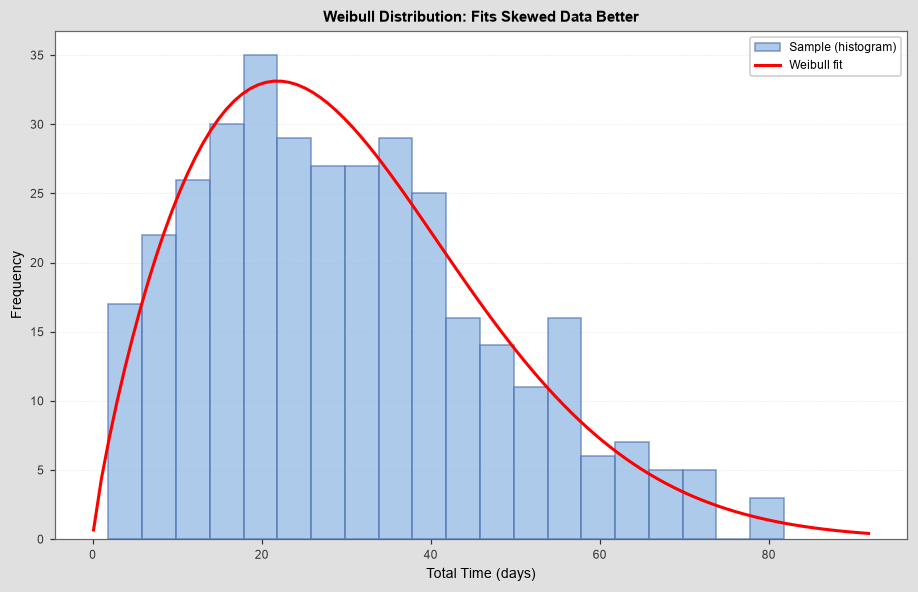

The Weibull distribution fits better!
The curve follows the histogram more closely.


In [7]:
# Fit Weibull distribution to skewed data
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (frequency, not density)
n_obs = len(data_skewed)
counts, bins, _ = ax.hist(data_skewed, bins=20, alpha=0.7, color=ms.HIST_FILL, 
                          edgecolor=ms.HIST_EDGE, label='Sample (histogram)')
bin_width = bins[1] - bins[0]

# Fit Weibull distribution and scale to frequency
weib_shape, weib_loc, weib_scale = stats.weibull_min.fit(data_skewed, floc=0)
x_range = np.linspace(0.1, data_skewed.max() + 10, 100)
# Scale PDF to frequency: pdf * n * bin_width
weib_pdf_scaled = stats.weibull_min.pdf(x_range, weib_shape, weib_loc, weib_scale) * n_obs * bin_width
ax.plot(x_range, weib_pdf_scaled, 'r-', lw=2, label='Weibull fit')

ax.set_xlabel('Total Time (days)')
ax.set_ylabel('Frequency')
ax.set_title('Weibull Distribution: Fits Skewed Data Better')
ax.legend()
plt.show()

print('The Weibull distribution fits better!')
print('The curve follows the histogram more closely.')

---

## 4. Lognormal Distribution

The **Lognormal distribution** is also skewed to the right and often used for:
- Time data
- Financial data
- Any data that is the product of many random factors

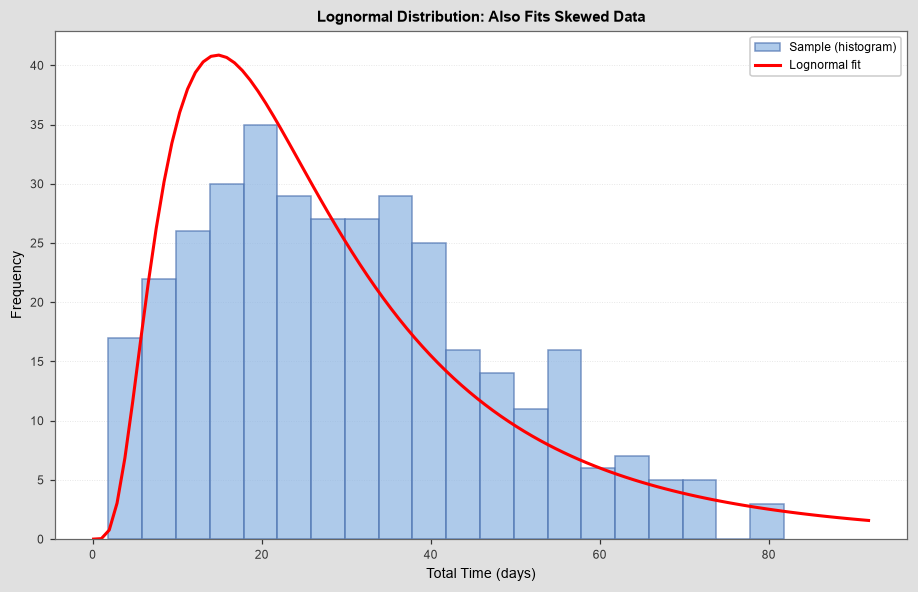

The Lognormal distribution also fits well!


In [8]:
# Fit Lognormal distribution to skewed data
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (frequency, not density)
n_obs = len(data_skewed)
counts, bins, _ = ax.hist(data_skewed, bins=20, alpha=0.7, color=ms.HIST_FILL,
                          edgecolor=ms.HIST_EDGE, label='Sample (histogram)')
bin_width = bins[1] - bins[0]

# Fit Lognormal distribution and scale to frequency
positive_data = data_skewed[data_skewed > 0]
lognorm_sigma = np.log(positive_data).std()
lognorm_scale = np.exp(np.log(positive_data).mean())

x_range = np.linspace(0.1, data_skewed.max() + 10, 100)
# Scale PDF to frequency: pdf * n * bin_width
lognorm_pdf_scaled = stats.lognorm.pdf(x_range, lognorm_sigma, 0, lognorm_scale) * n_obs * bin_width
ax.plot(x_range, lognorm_pdf_scaled, 'r-', lw=2, label='Lognormal fit')

ax.set_xlabel('Total Time (days)')
ax.set_ylabel('Frequency')
ax.set_title('Lognormal Distribution: Also Fits Skewed Data')
ax.legend()
plt.show()

print('The Lognormal distribution also fits well!')

---

## Comparing All Three Distributions

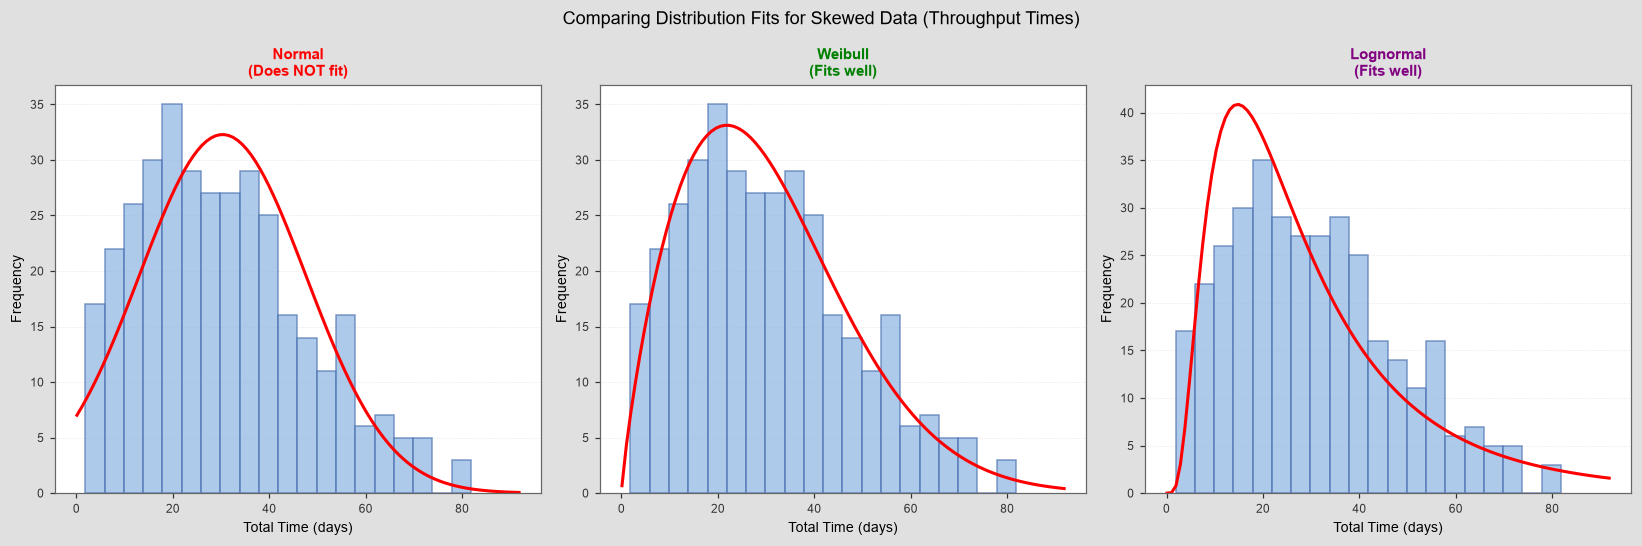

Peak heights: Normal=32.3, Weibull=33.1, Lognormal=40.9

Both Weibull and Lognormal fit the skewed data better than Normal.
To determine which fits BEST, use a probability plot (next video).


In [9]:
# Compare Normal, Weibull, and Lognormal fits
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

n_obs = len(data_skewed)
x_range = np.linspace(0.1, data_skewed.max() + 10, 100)

# Normal fit
counts, bins, _ = axes[0].hist(data_skewed, bins=20, alpha=0.7, color=ms.HIST_FILL, edgecolor=ms.HIST_EDGE)
bin_width = bins[1] - bins[0]
norm_mu, norm_sigma = stats.norm.fit(data_skewed)
norm_pdf_scaled = stats.norm.pdf(x_range, norm_mu, norm_sigma) * n_obs * bin_width
axes[0].plot(x_range, norm_pdf_scaled, 'r-', lw=2)
axes[0].set_title('Normal\n(Does NOT fit)', color='red')
axes[0].set_xlabel('Total Time (days)')
axes[0].set_ylabel('Frequency')

# Weibull fit
axes[1].hist(data_skewed, bins=20, alpha=0.7, color=ms.HIST_FILL, edgecolor=ms.HIST_EDGE)
weib_shape, weib_loc, weib_scale = stats.weibull_min.fit(data_skewed, floc=0)
weib_pdf_scaled = stats.weibull_min.pdf(x_range, weib_shape, weib_loc, weib_scale) * n_obs * bin_width
axes[1].plot(x_range, weib_pdf_scaled, 'r-', lw=2)
axes[1].set_title('Weibull\n(Fits well)', color='green')
axes[1].set_xlabel('Total Time (days)')
axes[1].set_ylabel('Frequency')

# Lognormal fit
axes[2].hist(data_skewed, bins=20, alpha=0.7, color=ms.HIST_FILL, edgecolor=ms.HIST_EDGE)
positive_data = data_skewed[data_skewed > 0]
lognorm_sigma = np.log(positive_data).std()
lognorm_scale = np.exp(np.log(positive_data).mean())
lognorm_pdf_scaled = stats.lognorm.pdf(x_range, lognorm_sigma, 0, lognorm_scale) * n_obs * bin_width
axes[2].plot(x_range, lognorm_pdf_scaled, 'r-', lw=2)
axes[2].set_title('Lognormal\n(Fits well)', color='purple')
axes[2].set_xlabel('Total Time (days)')
axes[2].set_ylabel('Frequency')

plt.suptitle('Comparing Distribution Fits for Skewed Data (Throughput Times)', fontsize=12)
plt.tight_layout()
plt.show()

# Show peak heights to demonstrate difference
print(f'Peak heights: Normal={norm_pdf_scaled.max():.1f}, Weibull={weib_pdf_scaled.max():.1f}, Lognormal={lognorm_pdf_scaled.max():.1f}')
print()
print('Both Weibull and Lognormal fit the skewed data better than Normal.')
print('To determine which fits BEST, use a probability plot (next video).')

---

## Summary: Distribution Shapes

```
NORMAL (Symmetrical)          WEIBULL/LOGNORMAL (Skewed Right)
                              
        ╱╲                              ╱╲
       ╱  ╲                            ╱  ╲
      ╱    ╲                          ╱    ╲___
     ╱      ╲                        ╱         ╲___
    ╱        ╲                      ╱              ╲___
───┴──────────┴───              ───┴──────────────────┴───
   Mean = Median                  Many small,    Long tail
                                  some very large
```

---

## Key Takeaways

- **Histogram** = sample data; **Curve** = fitted population distribution
- **Normal distribution:** Symmetrical, bell-shaped, most common
- **Weibull distribution:** Skewed right, used for time data
- **Lognormal distribution:** Skewed right, also used for time data
- **Skewed data:** Normal distribution will NOT fit; use Weibull or Lognormal
- **Next step:** Use probability plots to determine which distribution fits best